1. Import Libraries and Load Data

In [1]:
import pandas as pd

url = "https://files.consumerfinance.gov/ccdb/complaints.csv.zip"

df = pd.read_csv(
    url,
    compression='zip',     
    on_bad_lines='skip',    
    low_memory=False       
)

print("Dataset Loaded Successfully!")
print(f"Total Rows: {len(df)}")
print(f"Total Columns: {len(df.columns)}")
print("\nColumn Names:")
print(df.columns.tolist())

df.head()

Dataset Loaded Successfully!
Total Rows: 11498701
Total Columns: 18

Column Names:
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2020-07-06,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,346XX,NaN,Other,Web,2020-07-06,Closed with explanation,Yes,NaN,3730948
1,2025-10-14,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information is missing that should be on the r...,NaN,NaN,"EQUIFAX, INC.",TX,75062,NaN,NaN,Web,2025-10-14,In progress,Yes,NaN,16558024
2,2025-10-10,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"EQUIFAX, INC.",GA,30341,NaN,NaN,Web,2025-10-10,In progress,Yes,NaN,16507707
3,2025-10-15,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,75287,NaN,NaN,Web,2025-10-15,In progress,Yes,NaN,16593757
4,2025-10-03,Debt collection,I do not know,False statements or representation,Attempted to collect wrong amount,NaN,NaN,Resurgent Capital Services L.P.,MS,38751,NaN,NaN,Web,2025-10-03,In progress,Yes,NaN,16359589


2. Select Relevant Columns

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = df[['Product', 'Consumer complaint narrative']].dropna()

print("Selected relevant columns and dropped null rows.")
print(f"Remaining Rows: {len(df)}")
df.head()

Selected relevant columns and dropped null rows.
Remaining Rows: 3410356


,Product,Consumer complaint narrative
7,"Credit reporting, credit repair services, or o...",These are not my accounts.
15,Credit reporting or other personal consumer re...,Kindly address this issue on my credit report....
21,Credit reporting or other personal consumer re...,There are XXXX collections being reported to t...
42,Credit reporting or other personal consumer re...,"Violation of Gramm-Leach-Bliley Act ( GLBA ), ..."
66,Credit reporting or other personal consumer re...,"Good day, filing this complaint to follow up m..."


3. Filter Only Target Categories

In [3]:
target_classes = [
    'Credit reporting, repair, or other',
    'Debt collection',
    'Consumer Loan',
    'Mortgage'
]

df = df[df['Product'].isin(target_classes)]

df = df.sample(50000, random_state=42)

print(df['Product'].value_counts())

Product
Debt collection    35941
Mortgage           13144
Consumer Loan        915
Name: count, dtype: int64


4. Encode Labels and Visualize Class Distribution

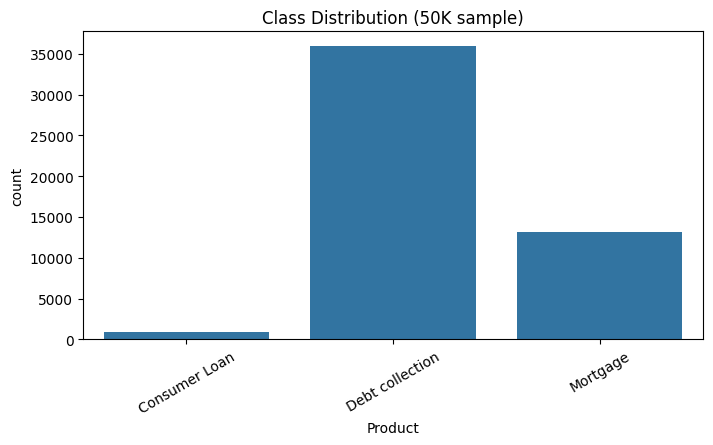

,Product,Consumer complaint narrative,label
900129,Consumer Loan,"My vehicle was repossessed on XXXX XXXX, 2015....",0
629728,Debt collection,I am not looking for this complaint to be chan...,1
9702648,Debt collection,XX/XX/year> [ Chrysler capital ] [ XXXX XXXX X...,1
9964598,Debt collection,I do not know who they are or what they are lo...,1
10364920,Debt collection,The XXXX XXXX XXXX XXXX and its agents stole ...,1


In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label'] = le.fit_transform(df['Product'])

plt.figure(figsize=(8,4))
sns.countplot(x='Product', data=df)
plt.title("Class Distribution (50K sample)")
plt.xticks(rotation=30)
plt.show()

df.head()

In [6]:
!pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.2/539.2 kB 10.4 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


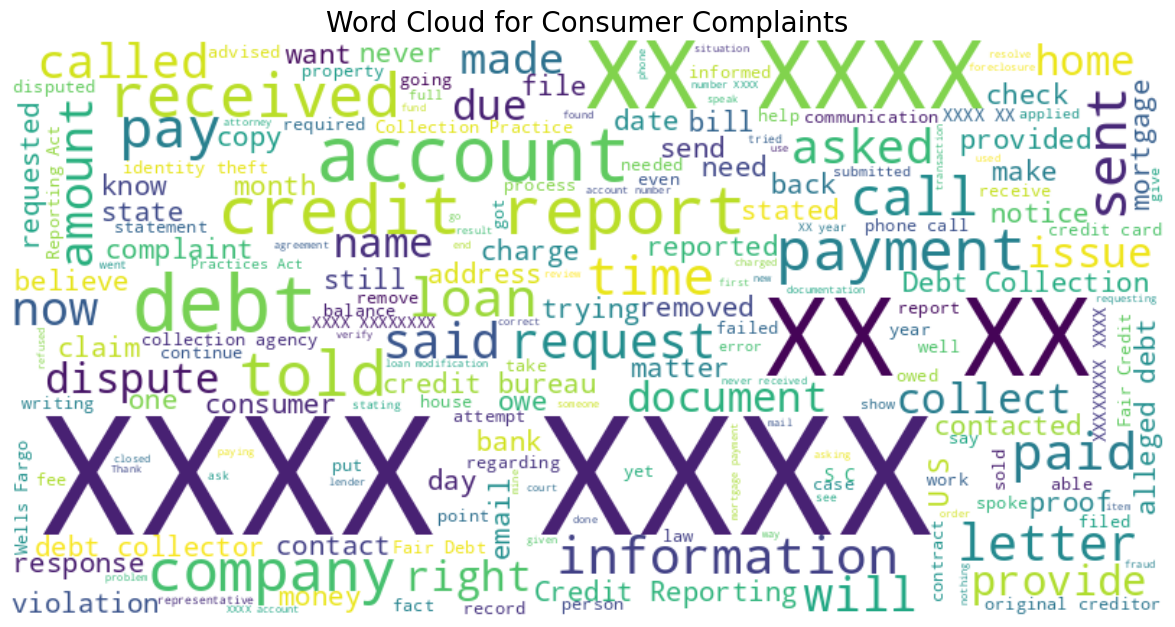

In [7]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Combine all complaint narratives (drop NaN values)
text = " ".join(df['Consumer complaint narrative'].dropna().astype(str).tolist())

# Create word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=STOPWORDS,  # removes common words like 'the', 'and'
    max_words=200
).generate(text)

# Display the word cloud
plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Consumer Complaints", fontsize=20)
plt.show()

 5. Text Cleaning

In [8]:
import re
import string

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['Consumer complaint narrative'].apply(clean_text)
df[['clean_text', 'Product']].head()

,clean_text,Product
900129,my vehicle was repossessed on xxxx xxxx i do n...,Consumer Loan
629728,i am not looking for this complaint to be chan...,Debt collection
9702648,xxxxyear chrysler capital xxxx xxxx xxxx xxxx ...,Debt collection
9964598,i do not know who they are or what they are lo...,Debt collection
10364920,the xxxx xxxx xxxx xxxx and its agents stole m...,Debt collection


6. Feature Engineering – Text Vectorization

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(df['clean_text'])
y = df['label']

print("TF-IDF vectorization complete.")

TF-IDF vectorization complete.


7. Split Dataset and Train Models

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f" {name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, preds, target_names=le.classes_))
    print("-"*60)

Training Logistic Regression...
 Logistic Regression Accuracy: 0.9651
                 precision    recall  f1-score   support

  Consumer Loan       0.77      0.36      0.49       168
Debt collection       0.97      0.98      0.98      7232
       Mortgage       0.95      0.95      0.95      2600

       accuracy                           0.97     10000
      macro avg       0.90      0.77      0.81     10000
   weighted avg       0.96      0.97      0.96     10000

------------------------------------------------------------
Training Naive Bayes...
 Naive Bayes Accuracy: 0.9491
                 precision    recall  f1-score   support

  Consumer Loan       0.89      0.10      0.17       168
Debt collection       0.97      0.97      0.97      7232
       Mortgage       0.89      0.96      0.92      2600

       accuracy                           0.95     10000
      macro avg       0.92      0.67      0.69     10000
   weighted avg       0.95      0.95      0.94     10000

-----------

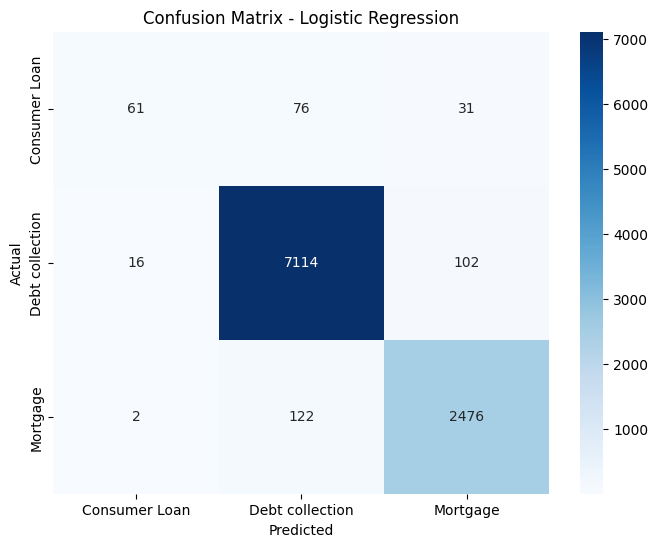

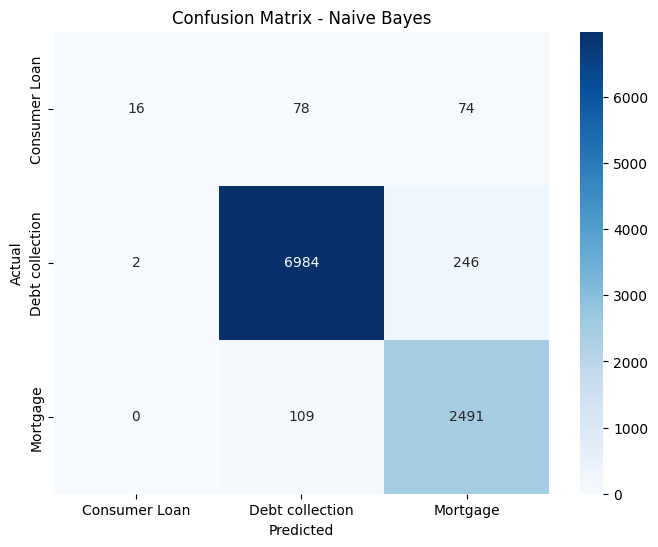

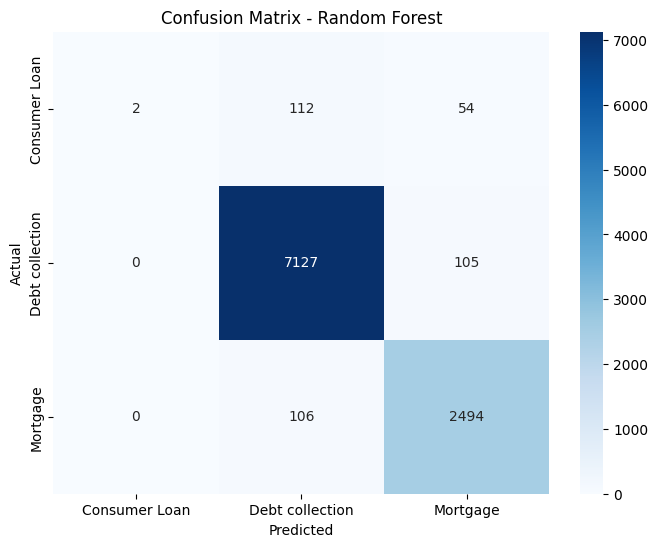

In [11]:
from sklearn.metrics import confusion_matrix
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    acc = accuracy_score(y_test, preds)
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


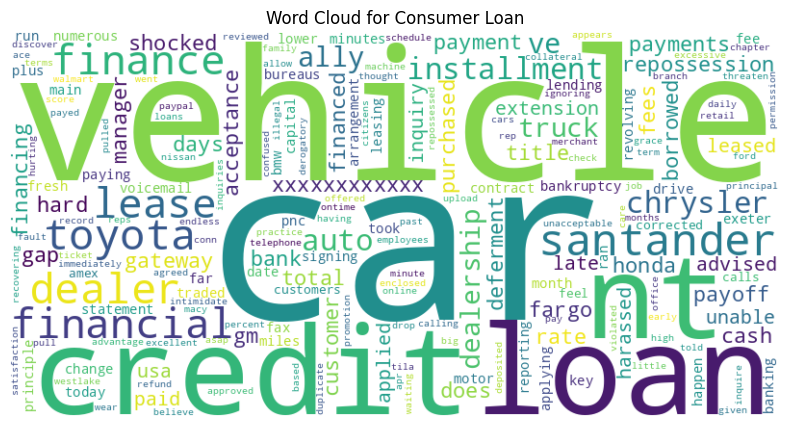

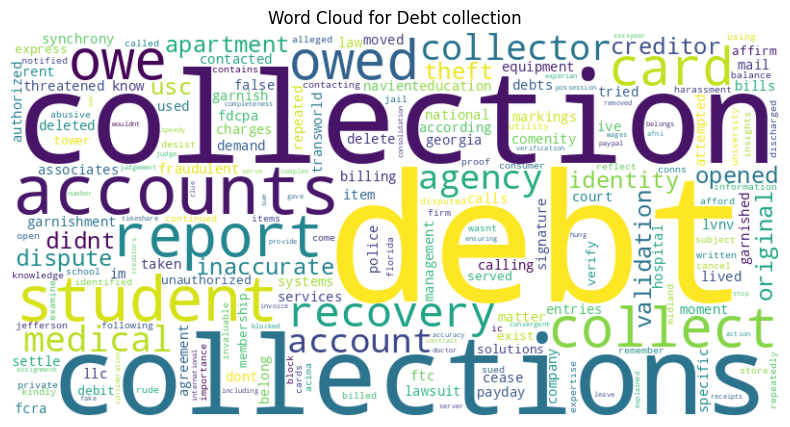

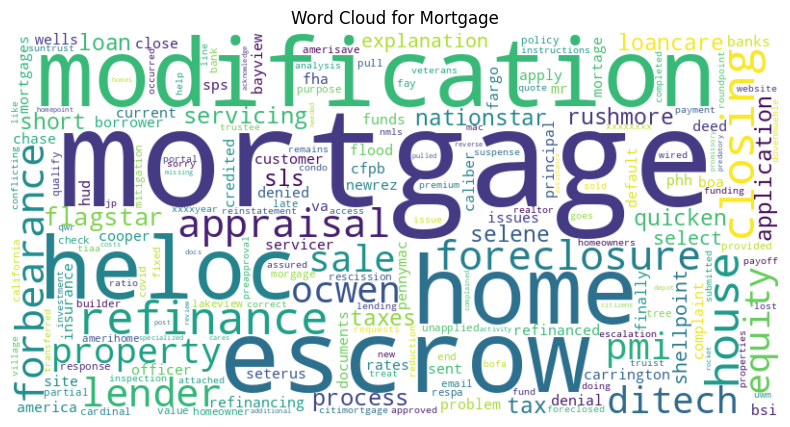

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np

model = models["Logistic Regression"]
feature_names = vectorizer.get_feature_names_out()

coef = model.coef_
for i, label in enumerate(le.classes_):
    coef_i = coef[i]
    word_weights = {feature_names[j]: coef_i[j] for j in range(len(feature_names))}
    
    wc = WordCloud(width=800, height=400, background_color='white')
    wc.generate_from_frequencies(word_weights)
    
    # Plot
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for {label}")
    plt.show()

8.Predictions

In [14]:
new_complaints = [
    "I was charged extra fees on my credit card and the company did not respond.",
    "The collection agency contacted me multiple times even after I disputed the debt.",
    "My mortgage payment was not processed correctly and I received a late notice."
]

X_new = vectorizer.transform(new_complaints)

predictions = models["Logistic Regression"].predict(X_new)

predicted_categories = le.inverse_transform(predictions)

for complaint, category in zip(new_complaints, predicted_categories):
    print(f"Complaint: {complaint}\nPredicted Category: {category}\n")

Complaint: I was charged extra fees on my credit card and the company did not respond.
Predicted Category: Debt collection

Complaint: The collection agency contacted me multiple times even after I disputed the debt.
Predicted Category: Debt collection

Complaint: My mortgage payment was not processed correctly and I received a late notice.
Predicted Category: Mortgage



*This task performs text classification on the Consumer Complaint Database, categorizing complaints into Credit Reporting, Debt Collection, Consumer Loan, and Mortgage. We cleaned the data, sampled 50,000 complaints, and converted the complaint text into TF-IDF features. Three models—Logistic Regression, Naive Bayes, and Random Forest—were trained and evaluated. Logistic Regression achieved the best performance with an accuracy of 96.5%, demonstrating an effective workflow for real-world text classification tasks.*